# Remind check time range

| Name          | SATCAT Number | First Manoeuvre | Last Manoeuvre  |
|--------------|--------------|----------------|----------------|
| Fengyun-2D   | 29640        | 2011-02-01     | 2015-04-10     |
| Fengyun-2E   | 33463        | 2011-03-17     | 2018-10-15     |
| Fengyun-2F   | 38049        | 2012-09-11     | 2022-01-05     |
| Fengyun-2H   | 43491        | 2019-01-18     | 2022-01-18     |
| Fengyun-4A   | 41882        | 2018-05-22     | 2022-02-21     |
| Sentinel-3A  | 41335        | 2016-02-23     | 2022-10-07     |
| Sentinel-3B  | 43437        | 2018-05-01     | 2022-10-07     |
| Sentinel-6A  | 46984        | 2020-11-24     | 2022-10-14     |
| Jason-1      | 26997        | 2001-12-12     | 2013-06-14     |
| Jason-2      | 33105        | 2008-06-24     | 2019-10-05     |
| Jason-3      | 41240        | 2016-01-20     | 2022-10-11     |
| SARAL        | 39086        | 2013-02-28     | 2022-09-22     |
| CryoSat-2    | 36508        | 2010-04-16     | 2022-10-06     |
| Haiyang-2A   | 37781        | 2011-09-29     | 2020-06-10     |
| TOPEX        | 22076        | 1992-08-18     | 2004-11-18     |


# Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

## Orbitals

In [2]:
# orbits

folder_path = "E:\project_a\satellite_data\orbital_elements"  # Change this to your actual folder path

filenames = [
    "CryoSat-2.csv", "Fengyun-2D.csv", "Fengyun-2E.csv", "Fengyun-2F.csv", "Fengyun-2H.csv",
    "Fengyun-4A.csv", "Haiyang-2A.csv", "Jason-1.csv", "Jason-2.csv", "Jason-3.csv",
    "SARAL.csv", "Sentinel-3A.csv", "Sentinel-3B.csv", "Sentinel-6A.csv", "TOPEX.csv"
]

orbitals = {file: pd.read_csv(os.path.join(folder_path, file)) for file in filenames}

orbitals["CryoSat-2.csv"].head()

,Unnamed: 0,eccentricity,argument of perigee,inclination,mean anomaly,Brouwer mean motion,right ascension
0,2010-04-25 12:13:31.467936,0.001190,3.773156,1.606104,-3.772437,0.063403,5.077397
1,2010-04-26 13:01:57.579456,0.001207,3.697660,1.606110,-3.696826,0.063403,5.081760
2,2010-04-27 22:06:32.422176,0.001224,3.603564,1.606097,-3.602503,0.063403,5.087575
3,2010-04-28 12:59:36.035519,0.001233,3.566036,1.606094,-3.564917,0.063403,5.090192
4,2010-04-29 00:34:12.213407,0.001252,3.529150,1.606097,-3.527920,0.063403,5.092225


In [3]:
for satellite, df in orbitals.items():
    # Check if 'Unnamed: 0' exists and rename it
    if 'Unnamed: 0' in df.columns:
        df['Unnamed: 0'] = pd.to_datetime(df['Unnamed: 0'], errors='coerce', utc=True).dt.strftime('%Y-%m-%d %H:%M')
        df = df.rename(columns={'Unnamed: 0': 'day_time'})

    # Update the dictionary with the modified DataFrame
    orbitals[satellite] = df
    
orbitals['CryoSat-2.csv'].head()

,day_time,eccentricity,argument of perigee,inclination,mean anomaly,Brouwer mean motion,right ascension
0,2010-04-25 12:13,0.001190,3.773156,1.606104,-3.772437,0.063403,5.077397
1,2010-04-26 13:01,0.001207,3.697660,1.606110,-3.696826,0.063403,5.081760
2,2010-04-27 22:06,0.001224,3.603564,1.606097,-3.602503,0.063403,5.087575
3,2010-04-28 12:59,0.001233,3.566036,1.606094,-3.564917,0.063403,5.090192
4,2010-04-29 00:34,0.001252,3.529150,1.606097,-3.527920,0.063403,5.092225


In [4]:
#check orbits element na
na_summary = {}

for satellite, df in orbitals.items():
    na_summary[satellite] = df.isna().sum()  # Count NaN values for each column

# Convert to DataFrame for better visualization
na_summary_df = pd.DataFrame(na_summary)

na_summary_df

,CryoSat-2.csv,Fengyun-2D.csv,Fengyun-2E.csv,Fengyun-2F.csv,Fengyun-2H.csv,Fengyun-4A.csv,Haiyang-2A.csv,Jason-1.csv,Jason-2.csv,Jason-3.csv,SARAL.csv,Sentinel-3A.csv,Sentinel-3B.csv,Sentinel-6A.csv,TOPEX.csv
day_time,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
eccentricity,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
argument of perigee,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
inclination,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
mean anomaly,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Brouwer mean motion,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
right ascension,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [5]:
# Dictionary to store duplicate row counts for each dataset
duplicate_summary = {}

for satellite, df in orbitals.items():
    duplicate_summary[satellite] = df.duplicated().sum()  # Count duplicated rows

# Convert to DataFrame for better visualization
duplicate_summary_df = pd.DataFrame.from_dict(duplicate_summary, orient='index', columns=['Duplicate Count'])

duplicate_summary_df

,Duplicate Count
CryoSat-2.csv,0
Fengyun-2D.csv,0
Fengyun-2E.csv,0
Fengyun-2F.csv,0
Fengyun-2H.csv,0
Fengyun-4A.csv,0
Haiyang-2A.csv,0
Jason-1.csv,0
Jason-2.csv,0
Jason-3.csv,0


In [6]:
orbitals['CryoSat-2.csv']

,day_time,eccentricity,argument of perigee,inclination,mean anomaly,Brouwer mean motion,right ascension
0,2010-04-25 12:13,0.001190,3.773156,1.606104,-3.772437,0.063403,5.077397
1,2010-04-26 13:01,0.001207,3.697660,1.606110,-3.696826,0.063403,5.081760
2,2010-04-27 22:06,0.001224,3.603564,1.606097,-3.602503,0.063403,5.087575
3,2010-04-28 12:59,0.001233,3.566036,1.606094,-3.564917,0.063403,5.090192
4,2010-04-29 00:34,0.001252,3.529150,1.606097,-3.527920,0.063403,5.092225
...,...,...,...,...,...,...,...
4303,2022-09-24 13:36,0.000224,4.715251,1.606211,-4.713593,0.063393,5.378394
4304,2022-09-25 12:46,0.000225,4.594886,1.606207,-4.593225,0.063393,5.382475
4305,2022-09-26 13:34,0.000227,4.469738,1.606202,-4.468071,0.063393,5.386845
4306,2022-09-27 04:27,0.000230,4.400036,1.606200,-4.398368,0.063393,5.389467


## Man1 for cs, haiyang, jason, sentinel and srl

In [7]:
# manverous - except fengyun+topex

available_files = [
    "E:\project_a\satellite_data\manoeuvres\cs2man.txt",
    "E:\project_a\satellite_data\manoeuvres\h2aman.txt",
    "E:\project_a\satellite_data\manoeuvres\ja1man.txt",
    "E:\project_a\satellite_data\manoeuvres\ja2man.txt",
    "E:\project_a\satellite_data\manoeuvres\ja3man.txt",
    "E:\project_a\satellite_data\manoeuvres\s3aman.txt",
    "E:\project_a\satellite_data\manoeuvres\s3bman.txt",
    "E:\project_a\satellite_data\manoeuvres\s6aman.txt",
    "E:\project_a\satellite_data\manoeuvres\srlman.txt"
    ]

columns_widths = [
    (0, 5),    # Satellite Name
    (6, 10),   # Beginning of maneuver: Year    
    (11, 14),  # Beginning of maneuver: Day of year       
    (15, 17),  # Beginning of maneuver: Hour 
    (18, 20),  # Beginning of maneuver: Minute 
    (21, 25),  # End of maneuver: Year 
    (26, 29),  # End of maneuver: Day of year
    (30, 32),  # End of maneuver: Hour 
    (33, 35),  # End of maneuver: Minute 
    (36, 39),  # Maneuver type
    (40, 43),  # Maneuver parameter type
    (44, 45),   # Number of burns
]

# Define column names
column_names = [
    "Satellite", "Start_Year", "Start_Day", "Start_Hour", "Start_Minute",
    "End_Year", "End_Day", "End_Hour", "End_Minute",
    "Maneuver_Type", "Parameter_Type", "Number_of_Burns"
]

def parse_line(line):
    return [line[start:end].strip() for start, end in columns_widths]

def process_maneuver_file(file_path):
    with open(file_path, "r") as txt_file:
        lines = txt_file.readlines()

    parsed_data = [parse_line(line) for line in lines]
    df = pd.DataFrame(parsed_data, columns=column_names)

    return df

In [8]:
maneuver_data = {}

for file_path in available_files:
    if os.path.exists(file_path):  # Ensure the file exists before processing
        maneuver_data[file_path[-10:-7]] = process_maneuver_file(file_path)
        
maneuver_data['cs2'].head()

,Satellite,Start_Year,Start_Day,Start_Hour,Start_Minute,End_Year,End_Day,End_Hour,End_Minute,Maneuver_Type,Parameter_Type,Number_of_Burns
0,CRYO2,2010,105,17,47,2010,105,17,48,,006,1
1,CRYO2,2010,123,17,55,2010,124,00,35,,006,2
2,CRYO2,2010,124,18,38,2010,124,18,48,,006,1
3,CRYO2,2010,125,17,44,2010,125,17,59,,006,1
4,CRYO2,2010,126,18,26,2010,126,18,51,,006,1


In [9]:
na_summary = {}

for key, df in maneuver_data.items():
    na_summary[key] = df.isna().sum()  # Count NaN values for each column

# Convert to DataFrame for better visualization
na_summary_df = pd.DataFrame(na_summary)

na_summary_df

,cs2,h2a,ja1,ja2,ja3,s3a,s3b,s6a,srl
Satellite,0,0,0,0,0,0,0,0,0
Start_Year,0,0,0,0,0,0,0,0,0
Start_Day,0,0,0,0,0,0,0,0,0
Start_Hour,0,0,0,0,0,0,0,0,0
Start_Minute,0,0,0,0,0,0,0,0,0
End_Year,0,0,0,0,0,0,0,0,0
End_Day,0,0,0,0,0,0,0,0,0
End_Hour,0,0,0,0,0,0,0,0,0
End_Minute,0,0,0,0,0,0,0,0,0
Maneuver_Type,0,0,0,0,0,0,0,0,0


In [10]:
# Dictionary to store duplicate row counts for each dataset
duplicate_summary = {}

for key, df in maneuver_data.items():
    duplicate_summary[key] = df.duplicated().sum()  # Count duplicated rows

# Convert to DataFrame for better visualization
duplicate_summary_df = pd.DataFrame.from_dict(duplicate_summary, orient='index', columns=['Duplicate Count'])

duplicate_summary_df

,Duplicate Count
cs2,0
h2a,0
ja1,0
ja2,0
ja3,0
s3a,0
s3b,0
s6a,0
srl,0


In [11]:
def convert_to_day_time(year, day, hour, minute):
    return datetime.strptime(f"{year} {day} {hour} {minute}", "%Y %j %H %M").strftime('%Y-%m-%d %H:%M')

In [12]:
for key, df in maneuver_data.items():
    df["begin_day_time"] = df.apply(lambda row: 
        convert_to_day_time(row["Start_Year"], row["Start_Day"], row["Start_Hour"], row["Start_Minute"]), axis=1)
    df["end_day_time"] = df.apply(lambda row: 
        convert_to_day_time(row["End_Year"], row["End_Day"], row["End_Hour"], row["End_Minute"]), axis=1)
    
    maneuver_data[key] = df[['Satellite', 'begin_day_time', 'end_day_time']] #'median_day_time']]

In [13]:
maneuver_data['s3b'].head()

,Satellite,begin_day_time,end_day_time
0,SEN3B,2018-04-30 09:20,2018-04-30 11:44
1,SEN3B,2018-05-01 11:19,2018-05-01 13:57
2,SEN3B,2018-05-02 15:08,2018-05-02 15:17
3,SEN3B,2018-05-04 10:36,2018-05-04 10:37
4,SEN3B,2018-05-08 09:25,2018-05-08 11:19


have checked https://github.com/dpshorten/TLE_observation_benchmark_dataset/blob/main/processed_files/manoeuvres_Sentinel-3B.yaml. The processed yaml data fron David shown the begin manverous time marked as the manverous time. 

In [14]:
na_summary = {}

for key, df in maneuver_data.items():
    na_summary[key] = df.isna().sum()  # Count NaN values for each column

# Convert to DataFrame for better visualization
na_summary_df = pd.DataFrame(na_summary)

na_summary_df

,cs2,h2a,ja1,ja2,ja3,s3a,s3b,s6a,srl
Satellite,0,0,0,0,0,0,0,0,0
begin_day_time,0,0,0,0,0,0,0,0,0
end_day_time,0,0,0,0,0,0,0,0,0


In [15]:
# Dictionary to store duplicate row counts for each dataset
duplicate_summary = {}

for key, df in maneuver_data.items():
    duplicate_summary[key] = df.duplicated().sum()  # Count duplicated rows

# Convert to DataFrame for better visualization
duplicate_summary_df = pd.DataFrame.from_dict(duplicate_summary, orient='index', columns=['Duplicate Count'])

duplicate_summary_df

,Duplicate Count
cs2,0
h2a,0
ja1,0
ja2,0
ja3,0
s3a,0
s3b,0
s6a,0
srl,0


## man2 for fengyun - duplicate in f2y

In [16]:
fengyun_path = [
    "E:\project_a\satellite_data\manoeuvres\manFY2D.txt.fy",
	"E:\project_a\satellite_data\manoeuvres\manFY2E.txt.fy",
	"E:\project_a\satellite_data\manoeuvres\manFY2F.txt.fy",
	"E:\project_a\satellite_data\manoeuvres\manFY2H.txt.fy",
	"E:\project_a\satellite_data\manoeuvres\manFY4A.txt.fy"
]

def process_fengyun_file(file_path):
    data = []
    with open(file_path, "r", encoding="utf-8") as file:
        for line in file:
            parts = line.strip().split('"')  # Split by double quotes
            if len(parts) >= 3:
                maneuver_type, satellite = parts[0].strip().rsplit(" ", 1)  # Extract type and satellite name
                begin_time = parts[1]  # Start time
                end_time = parts[3]  # End time

                # Convert timestamps to standard format (YYYY-MM-DD HH:MM)
                try:
                    begin_day_time = datetime.strptime(begin_time, "%Y-%m-%dT%H:%M:%S CST").strftime('%Y-%m-%d %H:%M')
                    end_day_time = datetime.strptime(end_time, "%Y-%m-%dT%H:%M:%S CST").strftime('%Y-%m-%d %H:%M')
                except ValueError:
                    begin_day_time, end_day_time = None, None, None

                data.append([satellite, begin_day_time, end_day_time])

    # Convert to DataFrame
    return pd.DataFrame(data, columns=["Satellite", "begin_day_time", "end_day_time"])

In [17]:
fengyun_data = {}
for file_path in fengyun_path:
    if os.path.exists(file_path):
        df_name = os.path.basename(file_path)[-11:-7]  # Use last 10 characters of filename
        fengyun_data[df_name] = process_fengyun_file(file_path)
    else:
        print(f"File not found: {file_path}")

for key, df in fengyun_data.items():
    df['Satellite'] = key

In [18]:
na_summary = {}

for key, df in fengyun_data.items():
    na_summary[key] = df.isna().sum()  # Count NaN values for each column

# Convert to DataFrame for better visualization
na_summary_df = pd.DataFrame(na_summary)

na_summary_df

,FY2D,FY2E,FY2F,FY2H,FY4A
Satellite,0,0,0,0,0
begin_day_time,0,0,0,0,0
end_day_time,0,0,0,0,0


In [19]:
# Dictionary to store duplicate row counts for each dataset
duplicate_summary = {}

for key, df in fengyun_data.items():
    duplicate_summary[key] = df.duplicated().sum()  # Count duplicated rows

# Convert to DataFrame for better visualization
duplicate_summary_df = pd.DataFrame.from_dict(duplicate_summary, orient='index', columns=['Duplicate Count'])

duplicate_summary_df

,Duplicate Count
FY2D,0
FY2E,0
FY2F,1
FY2H,0
FY4A,0


In [20]:
fengyun_data['FY2F'][fengyun_data['FY2F'].duplicated()]

,Satellite,begin_day_time,end_day_time
32,FY2F,2017-09-05 16:30,2017-09-05 17:30


In [21]:
fengyun_data['FY2F'] = fengyun_data['FY2F'].drop_duplicates()

In [22]:
fengyun_data['FY2F'].head()

,Satellite,begin_day_time,end_day_time
0,FY2F,2022-01-05 08:30,2022-01-05 09:30
1,FY2F,2021-11-15 15:30,2021-11-15 16:30
2,FY2F,2021-09-23 16:00,2021-09-23 17:00
3,FY2F,2021-08-04 15:00,2021-08-04 16:00
4,FY2F,2021-06-15 16:00,2021-06-15 17:00


In [23]:
maneuver_data.update(fengyun_data)

## MAN3 topex

In [24]:
# Define TOPEX maneuver file path
topex_path = r"E:\project_a\satellite_data\manoeuvres\topman.txt"  # Adjust if needed

topex_columns_widths = [
    (0, 5),   # Satellite Name
    (6, 10),  # Beginning of maneuver: Year    
    (11, 14), # Beginning of maneuver: Day of year       
    (15, 17), # Beginning of maneuver: Hour 
    (18, 20), # Beginning of maneuver: Minute 
    (21, 25), # End of maneuver: Year 
    (26, 29), # End of maneuver: Day of year
    (30, 32), # End of maneuver: Hour 
    (33, 35)  # End of maneuver: Minute 
]

with open(topex_path, 'r') as txt_file:
    lines = txt_file.readlines()

# Parsing each line into a list of values
parsed_data_topex = [[line[start:end].strip() for start, end in topex_columns_widths] for line in lines]#[parse_line(line) for line in lines]

# Defining the column names
column_names_topex = [
    'Satellite', 'Start_Year', 'Start_Day', 'Start_Hour', 'Start_Minute',
    'End_Year', 'End_Day', 'End_Hour', 'End_Minute'
]

# Creating a dataframe with the text file data
topex_df = pd.DataFrame(parsed_data_topex, columns = column_names_topex)

# Checking the dataframe
topex_df.head()

,Satellite,Start_Year,Start_Day,Start_Hour,Start_Minute,End_Year,End_Day,End_Hour,End_Minute
0,TOPEX,1992,230,18,22,1992,230,18,22
1,TOPEX,1992,233,17,23,1992,233,17,23
2,TOPEX,1992,240,18,13,1992,240,18,13
3,TOPEX,1992,246,18,22,1992,246,18,22
4,TOPEX,1992,252,18,49,1992,252,18,49


In [25]:
topex_df["begin_day_time"] = topex_df.apply(lambda row: 
    convert_to_day_time(row["Start_Year"], row["Start_Day"], row["Start_Hour"], row["Start_Minute"]), axis=1)

topex_df["end_day_time"] = topex_df.apply(lambda row: 
    convert_to_day_time(row["End_Year"], row["End_Day"], row["End_Hour"], row["End_Minute"]), axis=1)

maneuver_data['TOP'] = topex_df[['Satellite', 'begin_day_time', 'end_day_time']]

In [26]:
na_summary = {}

for key, df in maneuver_data.items():
    na_summary[key] = df.isna().sum()  # Count NaN values for each column

# Convert to DataFrame for better visualization
na_summary_df = pd.DataFrame(na_summary)

na_summary_df

,cs2,h2a,ja1,ja2,ja3,s3a,s3b,s6a,srl,FY2D,FY2E,FY2F,FY2H,FY4A,TOP
Satellite,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
begin_day_time,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
end_day_time,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [27]:
# Dictionary to store duplicate row counts for each dataset
duplicate_summary = {}

for key, df in maneuver_data.items():
    duplicate_summary[key] = df.duplicated().sum()  # Count duplicated rows

# Convert to DataFrame for better visualization
duplicate_summary_df = pd.DataFrame.from_dict(duplicate_summary, orient='index', columns=['Duplicate Count'])

duplicate_summary_df

,Duplicate Count
cs2,0
h2a,0
ja1,0
ja2,0
ja3,0
s3a,0
s3b,0
s6a,0
srl,0
FY2D,0


In [28]:
for key, df in maneuver_data.items():
    
    df = df.copy()  # ensure 

    # ensure datetime
    df["begin_day_time"] = pd.to_datetime(df["begin_day_time"])
    df["end_day_time"] = pd.to_datetime(df["end_day_time"])

    # find median day time 
    df["median_day_time"] = df["begin_day_time"] + (df["end_day_time"] - df["begin_day_time"]) / 2
    
    maneuver_data[key] = df 

In [29]:
maneuver_data['cs2'].head()

,Satellite,begin_day_time,end_day_time,median_day_time
0,CRYO2,2010-04-15 17:47:00,2010-04-15 17:48:00,2010-04-15 17:47:30
1,CRYO2,2010-05-03 17:55:00,2010-05-04 00:35:00,2010-05-03 21:15:00
2,CRYO2,2010-05-04 18:38:00,2010-05-04 18:48:00,2010-05-04 18:43:00
3,CRYO2,2010-05-05 17:44:00,2010-05-05 17:59:00,2010-05-05 17:51:30
4,CRYO2,2010-05-06 18:26:00,2010-05-06 18:51:00,2010-05-06 18:38:30


## timesteps

In [30]:
cs2orb = orbitals['CryoSat-2.csv']
fy2dorb = orbitals['Fengyun-2D.csv']
fy2eorb = orbitals['Fengyun-2E.csv']
fy2forb = orbitals['Fengyun-2F.csv']
fy2horb = orbitals['Fengyun-2H.csv']
fy4aorb = orbitals['Fengyun-4A.csv']
h2aorb = orbitals['Haiyang-2A.csv']
ja1orb = orbitals['Jason-1.csv']
ja2orb = orbitals['Jason-2.csv']
ja3orb = orbitals['Jason-3.csv']
srlorb = orbitals['SARAL.csv']
s3aorb = orbitals['Sentinel-3A.csv']
s3borb = orbitals['Sentinel-3B.csv']
s6aorb = orbitals['Sentinel-6A.csv']
toporb = orbitals['TOPEX.csv']

In [31]:
orb_lst= [cs2orb, fy2dorb, fy2eorb, fy2forb, fy2horb, fy4aorb, h2aorb, ja1orb, ja2orb, ja3orb, srlorb, s3aorb, s3borb, s6aorb, toporb]

In [32]:
# for orb in orb_lst:
#     orb['day_time'] = pd.to_datetime(orb['day_time'], errors='coerce').dt.normalize()
#     orb.set_index('day_time', inplace=True)
    
#     orb.sort_index(inplace=True)
    
#     time_diffs = orb.index.to_series().diff().dt.days.dropna()
    
#     print("Dates Range from:", orb.index.min(), "to", orb.index.max())
#     print(f"Time Stamps Difference Count for:\n{time_diffs.value_counts().sort_index()}")

# Initial Check

In [33]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

## CS2

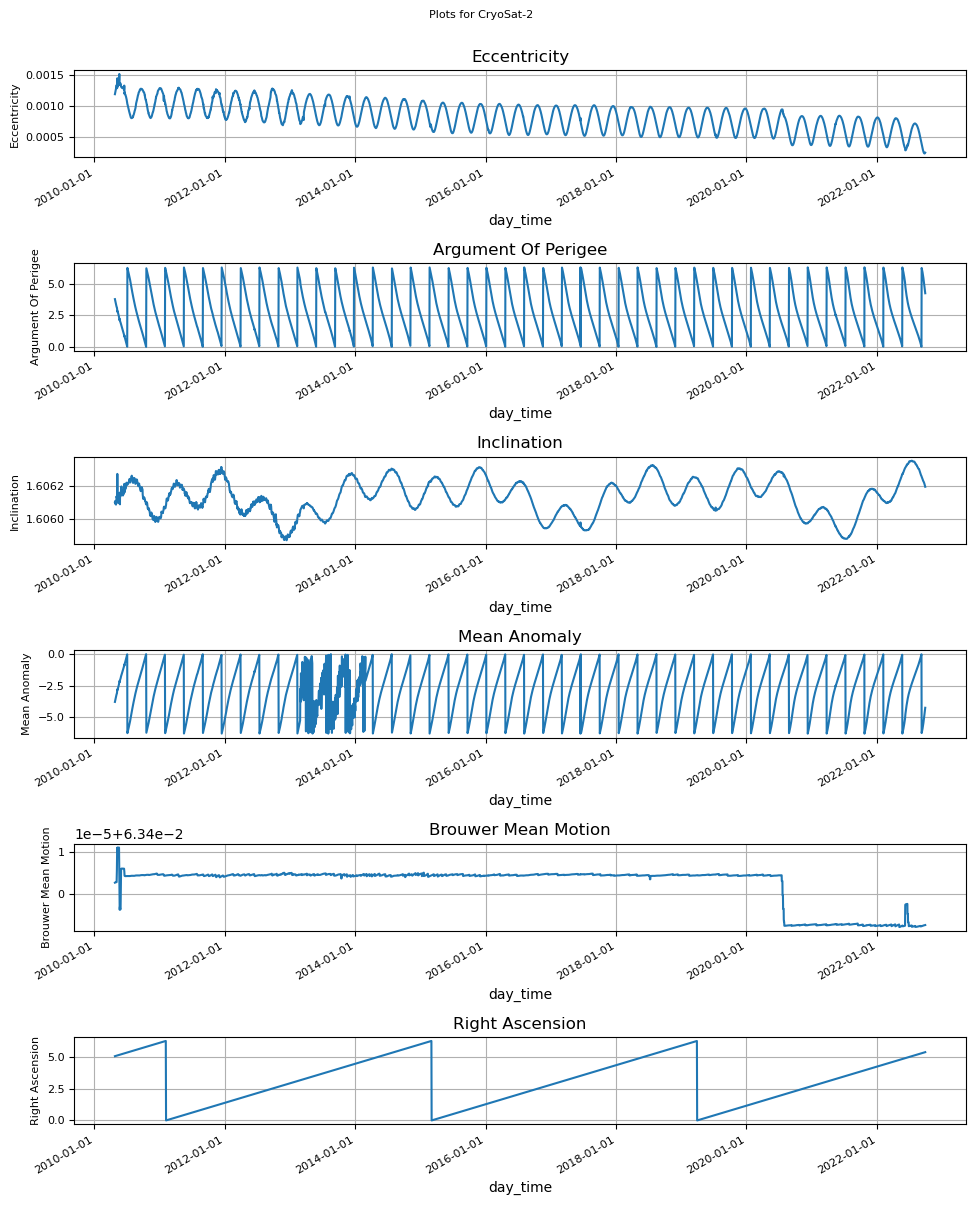

In [34]:
cs2orb['day_time'] = pd.to_datetime(cs2orb['day_time'], errors='coerce')
cs2orb.set_index('day_time', inplace=True)

# Get the columns to plot
columns_to_plot = cs2orb.columns
num_columns = len(columns_to_plot)

# Create a figure with subplots for each column
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 2*num_columns), sharex=False)

# Plot each column in its own subplot
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    cs2orb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x',  labelsize=8)
    ax.tick_params(axis='y',  labelsize=8)

# Adjust layout and show plot
plt.suptitle("Plots for CryoSat-2", y=1, fontsize=8)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

time series looks good

## FY2D

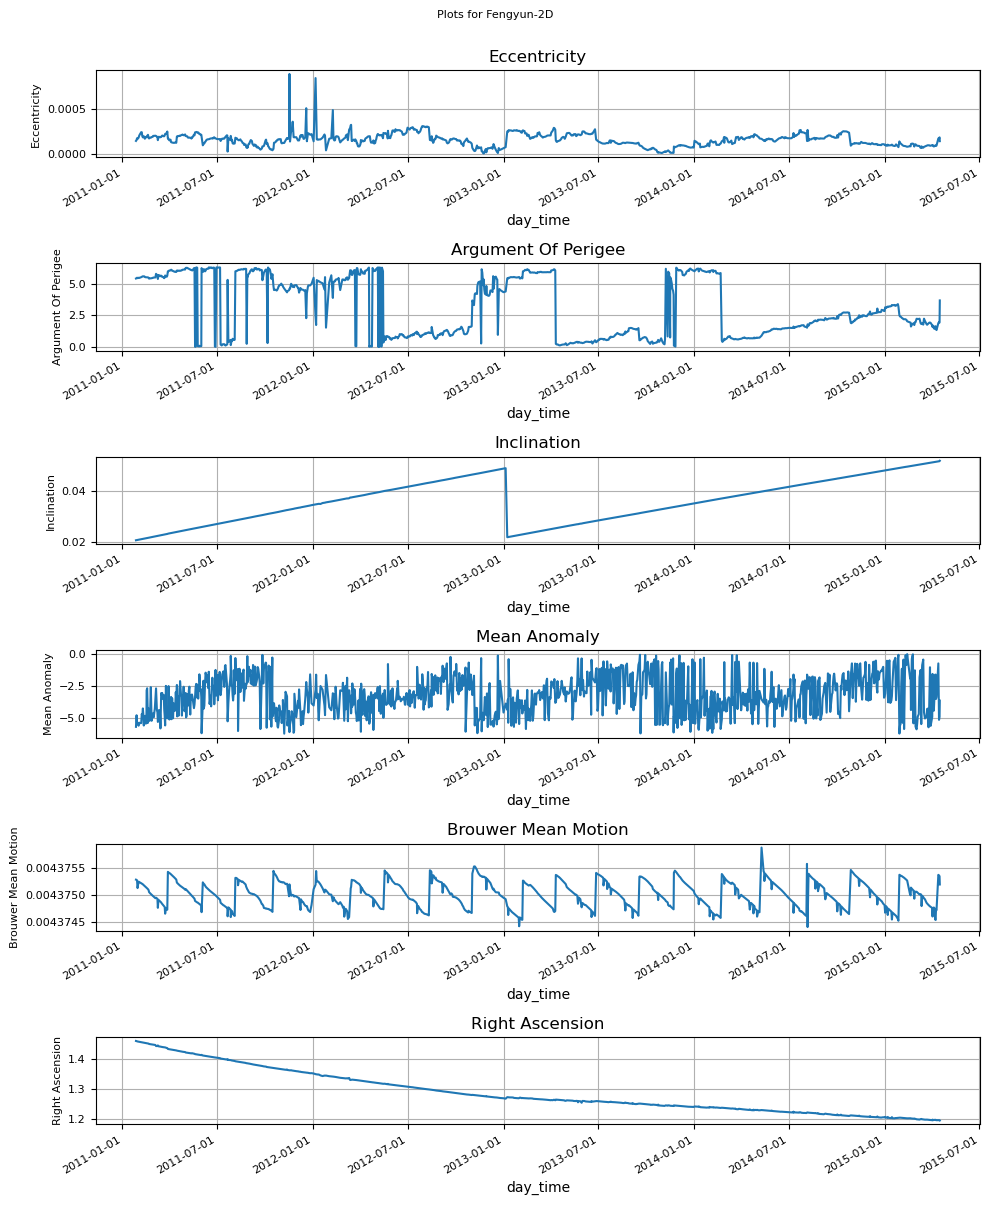

In [35]:
fy2dorb['day_time'] = pd.to_datetime(fy2dorb['day_time'], errors='coerce')
fy2dorb.set_index('day_time', inplace=True)

# Get the columns to plot
columns_to_plot = fy2dorb.columns
num_columns = len(columns_to_plot)

# Create a figure with subplots for each column
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 2*num_columns), sharex=False)

# Plot each column in its own subplot
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    fy2dorb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x',  labelsize=8)
    ax.tick_params(axis='y',  labelsize=8)

# Adjust layout and show plot
plt.suptitle("Plots for Fengyun-2D", y=1, fontsize=8)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

## FY2E

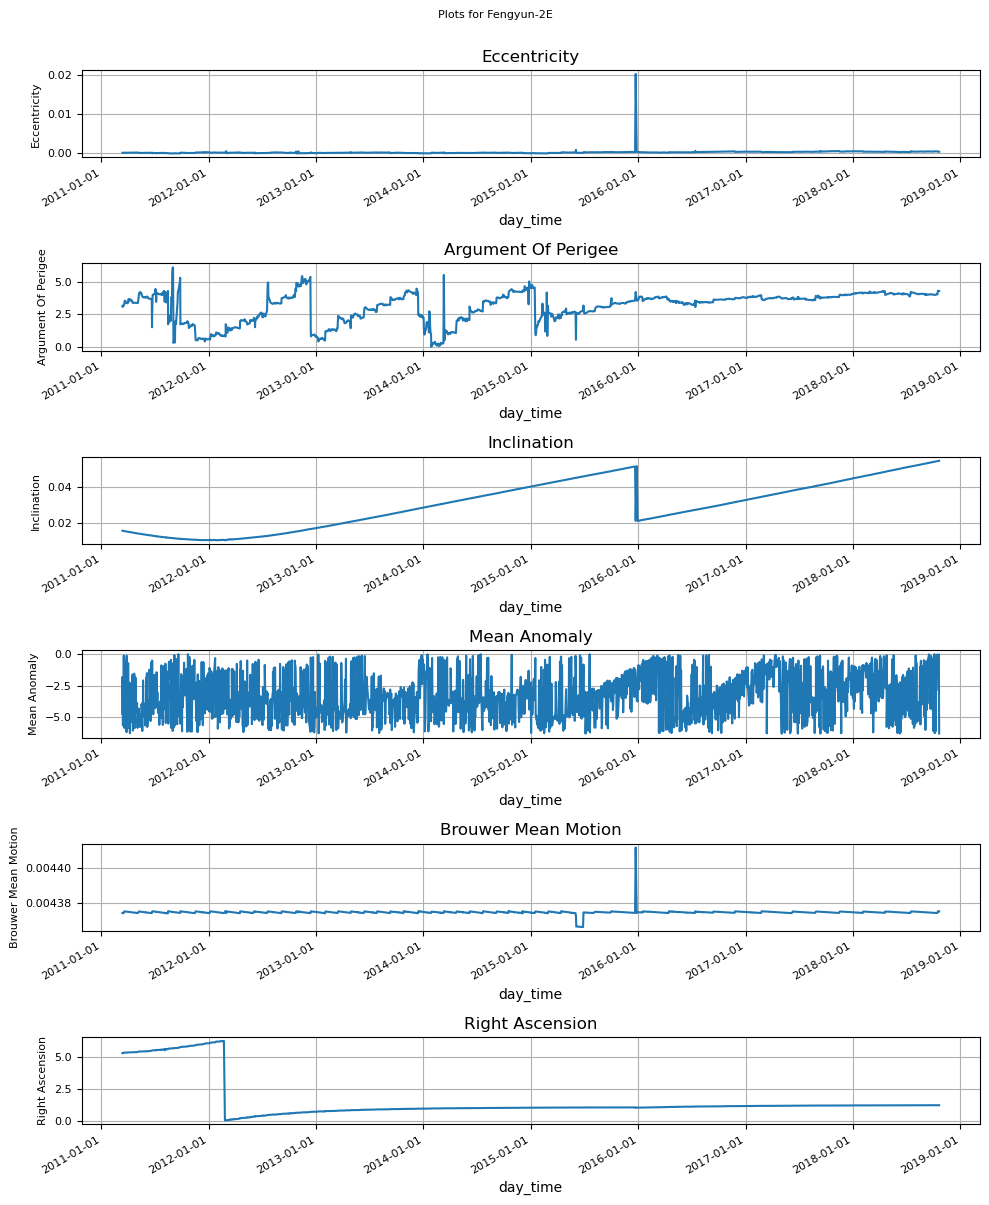

In [36]:
fy2eorb['day_time'] = pd.to_datetime(fy2eorb['day_time'], errors='coerce')
fy2eorb.set_index('day_time', inplace=True)

# Get the columns to plot
columns_to_plot = fy2eorb.columns
num_columns = len(columns_to_plot)

# Create a figure with subplots for each column
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 2*num_columns), sharex=False)

# Plot each column in its own subplot
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    fy2eorb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x',  labelsize=8)
    ax.tick_params(axis='y',  labelsize=8)

# Adjust layout and show plot
plt.suptitle("Plots for Fengyun-2E", y=1, fontsize=8)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

## FY2F

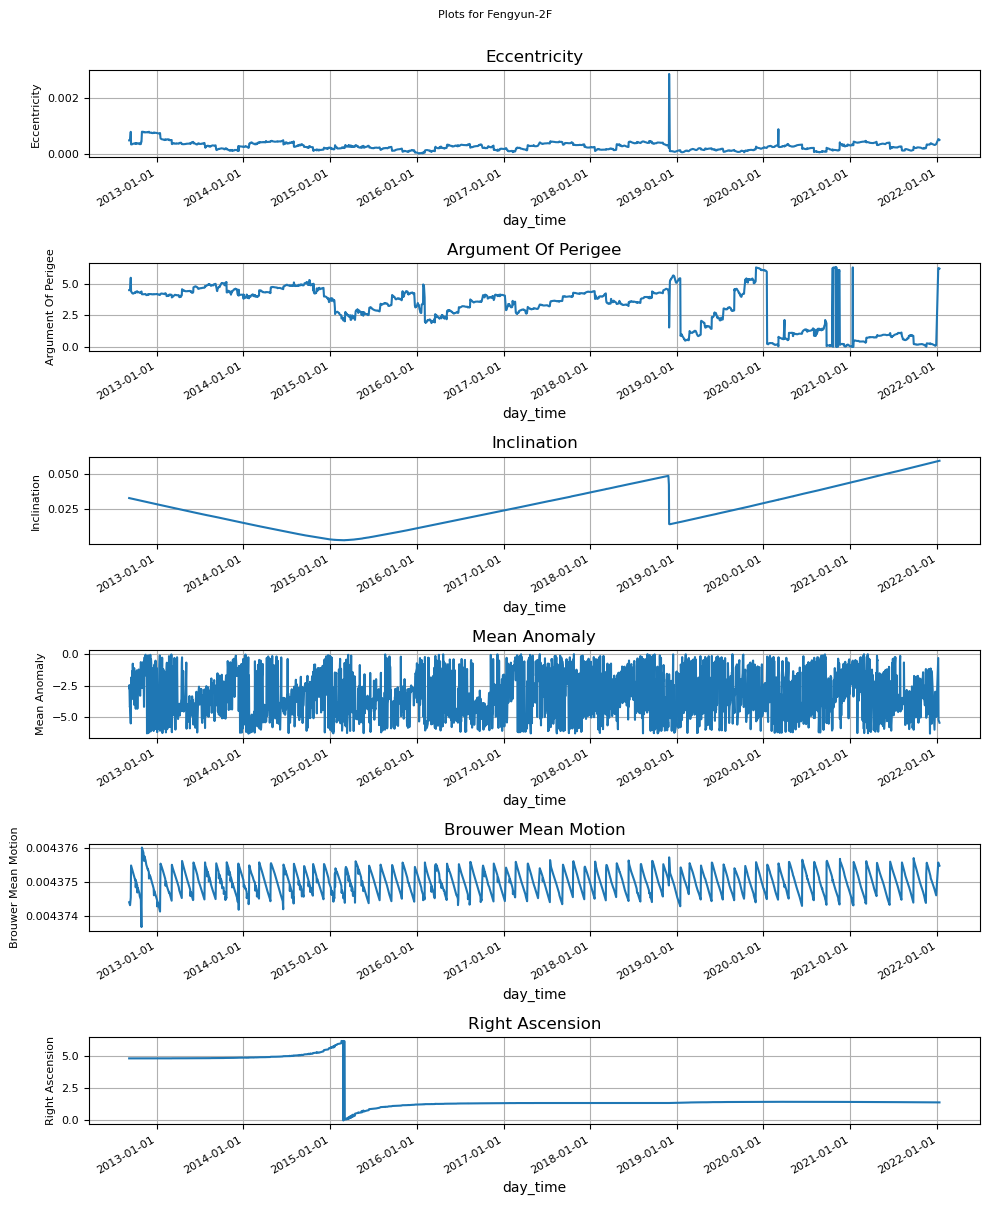

In [37]:
fy2forb['day_time'] = pd.to_datetime(fy2forb['day_time'], errors='coerce')
fy2forb.set_index('day_time', inplace=True)

# Get the columns to plot
columns_to_plot = fy2forb.columns
num_columns = len(columns_to_plot)

# Create a figure with subplots for each column
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 2*num_columns), sharex=False)

# Plot each column in its own subplot
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    fy2forb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x',  labelsize=8)
    ax.tick_params(axis='y',  labelsize=8)

# Adjust layout and show plot
plt.suptitle("Plots for Fengyun-2F", y=1, fontsize=8)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

## FY2H

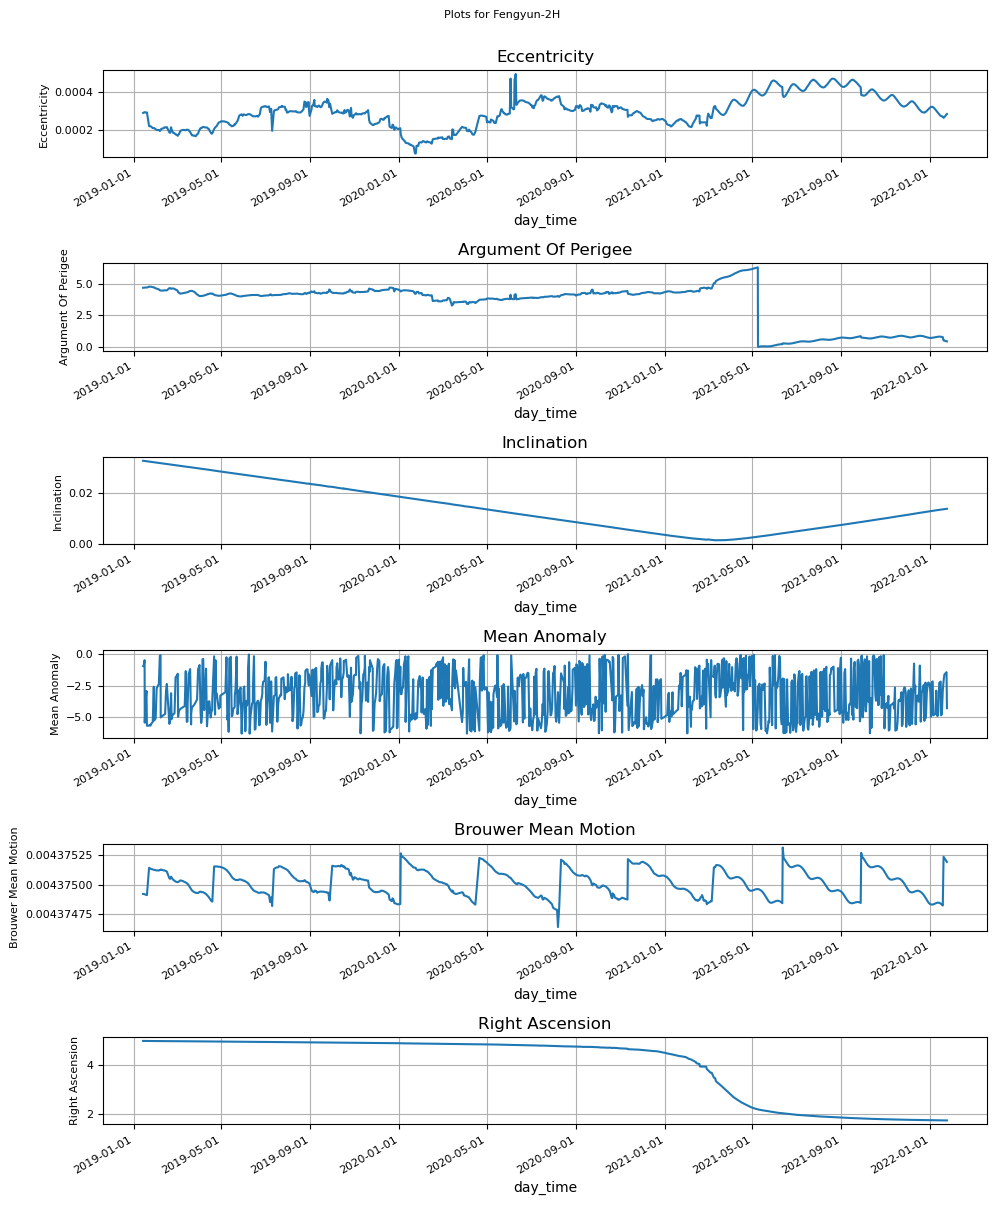

In [38]:
fy2horb['day_time'] = pd.to_datetime(fy2horb['day_time'], errors='coerce')
fy2horb.set_index('day_time', inplace=True)

# Get the columns to plot
columns_to_plot = fy2horb.columns
num_columns = len(columns_to_plot)

# Create a figure with subplots for each column
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 2*num_columns), sharex=False)

# Plot each column in its own subplot
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    fy2horb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x',  labelsize=8)
    ax.tick_params(axis='y',  labelsize=8)

# Adjust layout and show plot
plt.suptitle("Plots for Fengyun-2H", y=1, fontsize=8)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

## FY4A

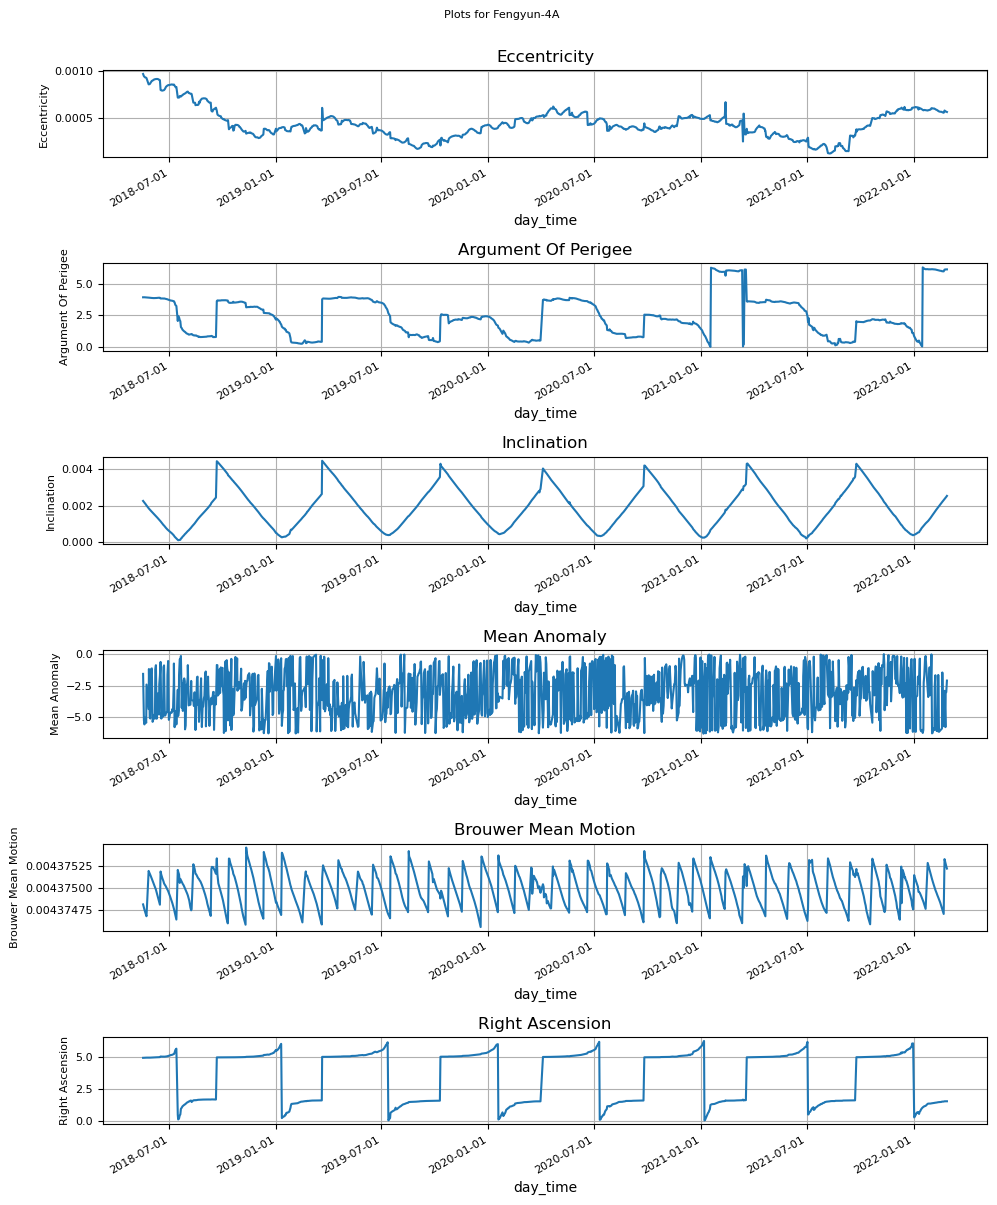

In [39]:
fy4aorb['day_time'] = pd.to_datetime(fy4aorb['day_time'], errors='coerce')
fy4aorb.set_index('day_time', inplace=True)

# Get the columns to plot
columns_to_plot = fy4aorb.columns
num_columns = len(columns_to_plot)

# Create a figure with subplots for each column
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 2*num_columns), sharex=False)

# Plot each column in its own subplot
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    fy4aorb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x',  labelsize=8)
    ax.tick_params(axis='y',  labelsize=8)

# Adjust layout and show plot
plt.suptitle("Plots for Fengyun-4A", y=1, fontsize=8)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

## HY2A

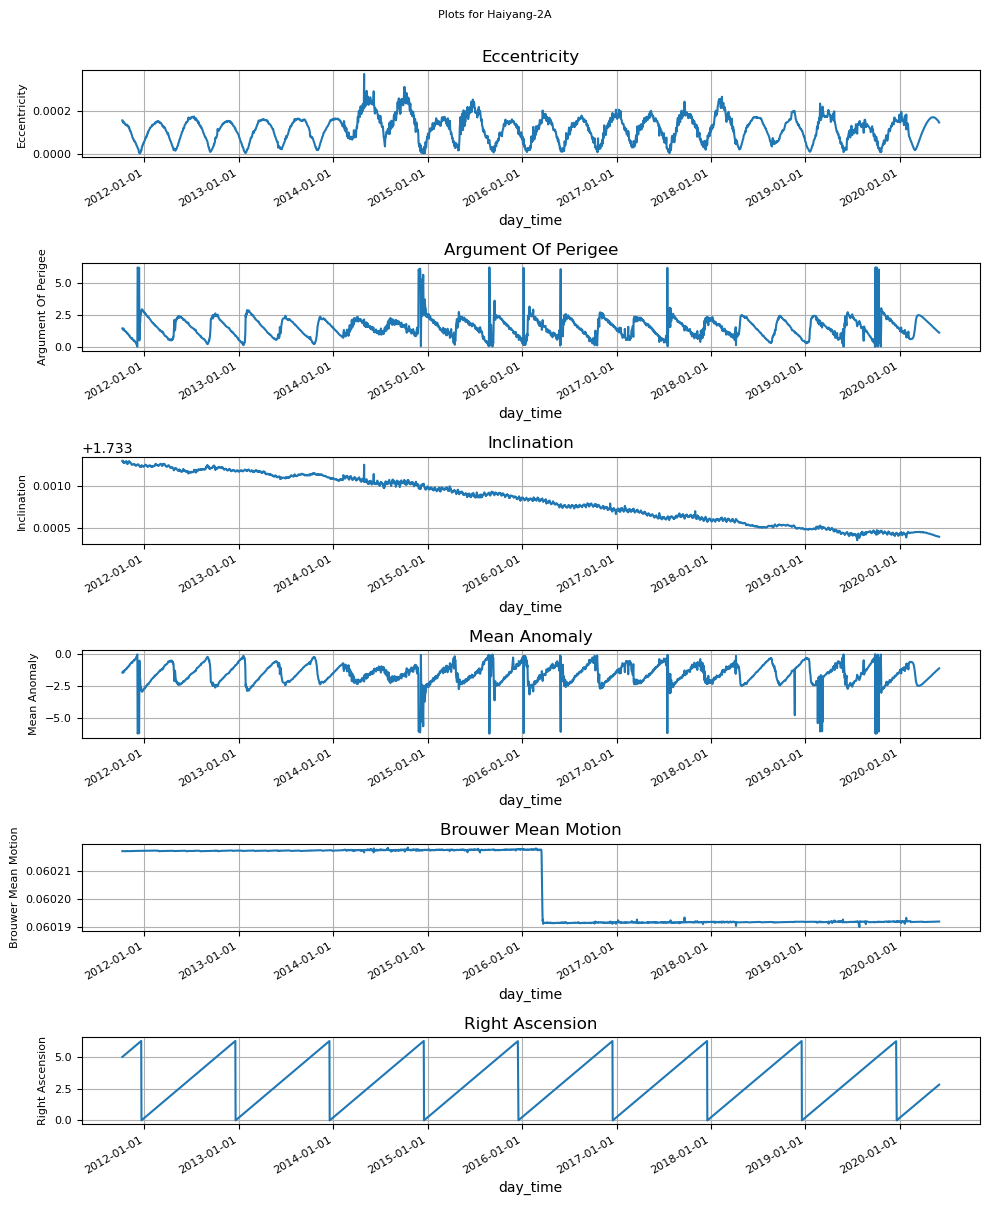

In [40]:
h2aorb['day_time'] = pd.to_datetime(h2aorb['day_time'], errors='coerce')
h2aorb.set_index('day_time', inplace=True)

# Get the columns to plot
columns_to_plot = h2aorb.columns
num_columns = len(columns_to_plot)

# Create a figure with subplots for each column
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 2*num_columns), sharex=False)

# Plot each column in its own subplot
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    h2aorb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x',  labelsize=8)
    ax.tick_params(axis='y',  labelsize=8)

# Adjust layout and show plot
plt.suptitle("Plots for Haiyang-2A", y=1, fontsize=8)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

## JASON1

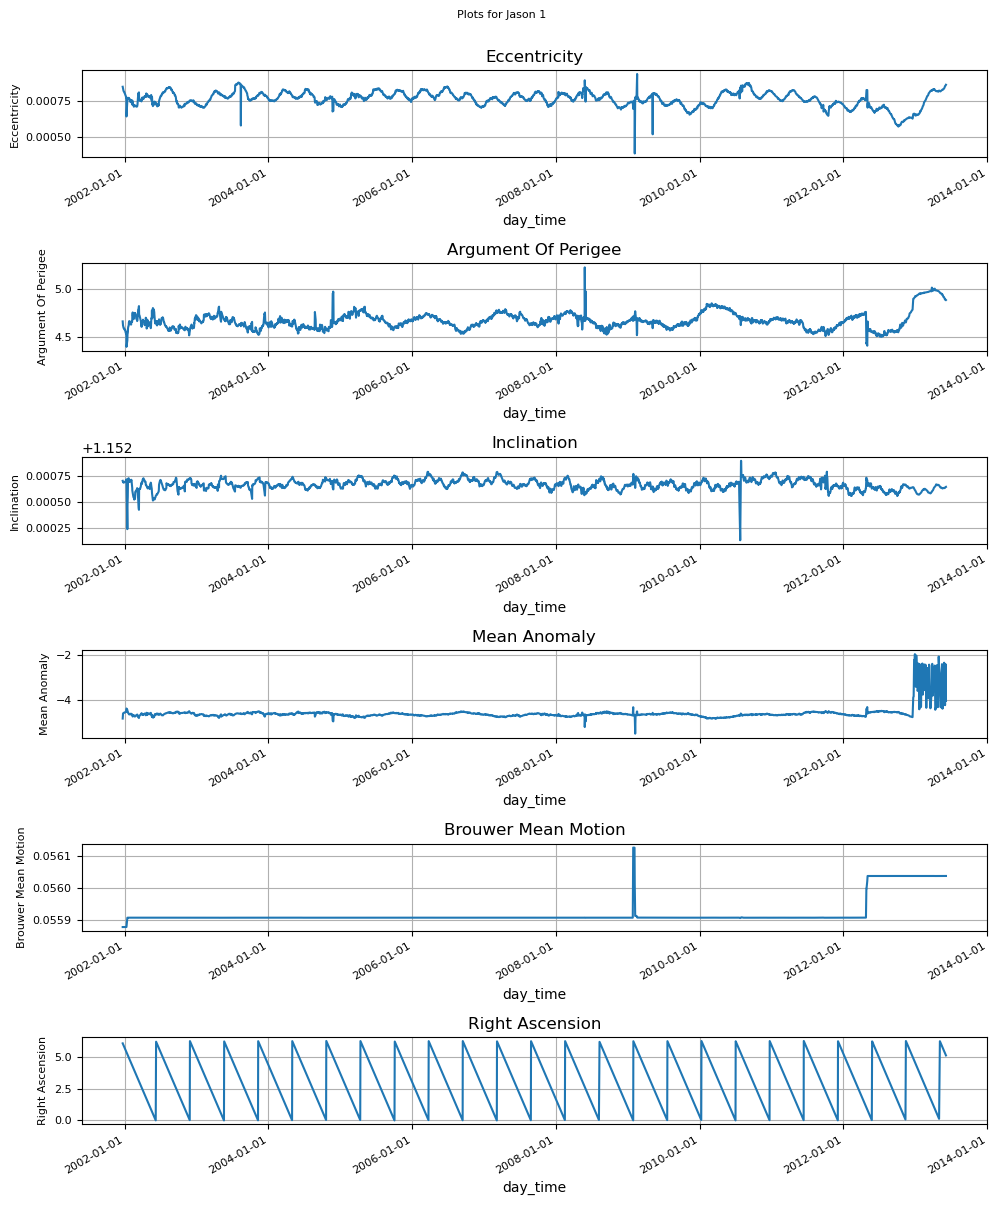

In [41]:
ja1orb['day_time'] = pd.to_datetime(ja1orb['day_time'], errors='coerce')
ja1orb.set_index('day_time', inplace=True)

# Get the columns to plot
columns_to_plot = ja1orb.columns
num_columns = len(columns_to_plot)

# Create a figure with subplots for each column
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 2*num_columns), sharex=False)

# Plot each column in its own subplot
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    ja1orb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x',  labelsize=8)
    ax.tick_params(axis='y',  labelsize=8)

# Adjust layout and show plot
plt.suptitle("Plots for Jason 1", y=1, fontsize=8)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

## JASON2

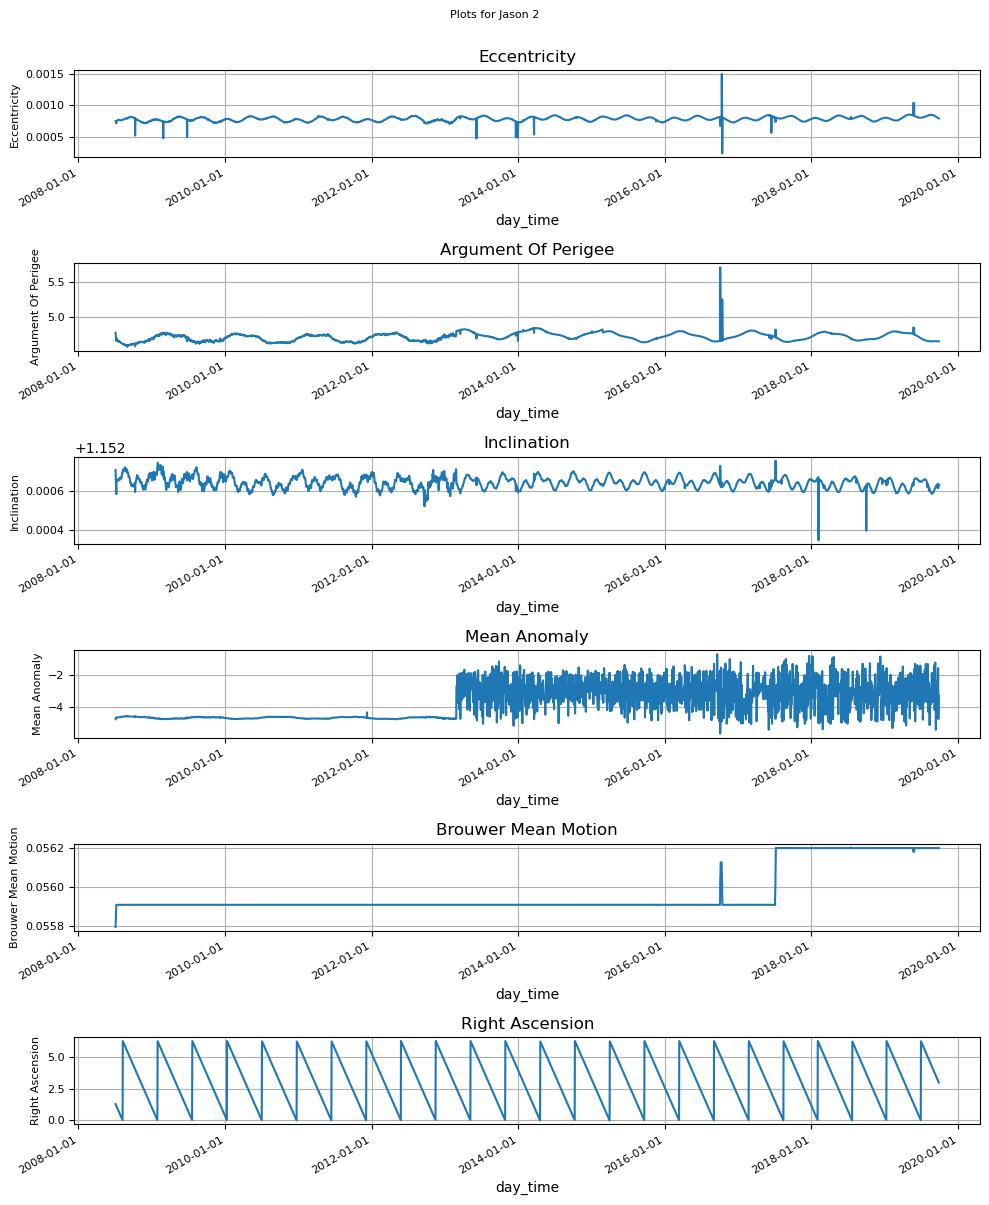

In [42]:
ja2orb['day_time'] = pd.to_datetime(ja2orb['day_time'], errors='coerce')
ja2orb.set_index('day_time', inplace=True)

# Get the columns to plot
columns_to_plot = ja2orb.columns
num_columns = len(columns_to_plot)

# Create a figure with subplots for each column
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 2*num_columns), sharex=False)

# Plot each column in its own subplot
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    ja2orb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x',  labelsize=8)
    ax.tick_params(axis='y',  labelsize=8)

# Adjust layout and show plot
plt.suptitle("Plots for Jason 2", y=1, fontsize=8)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

## JASON3

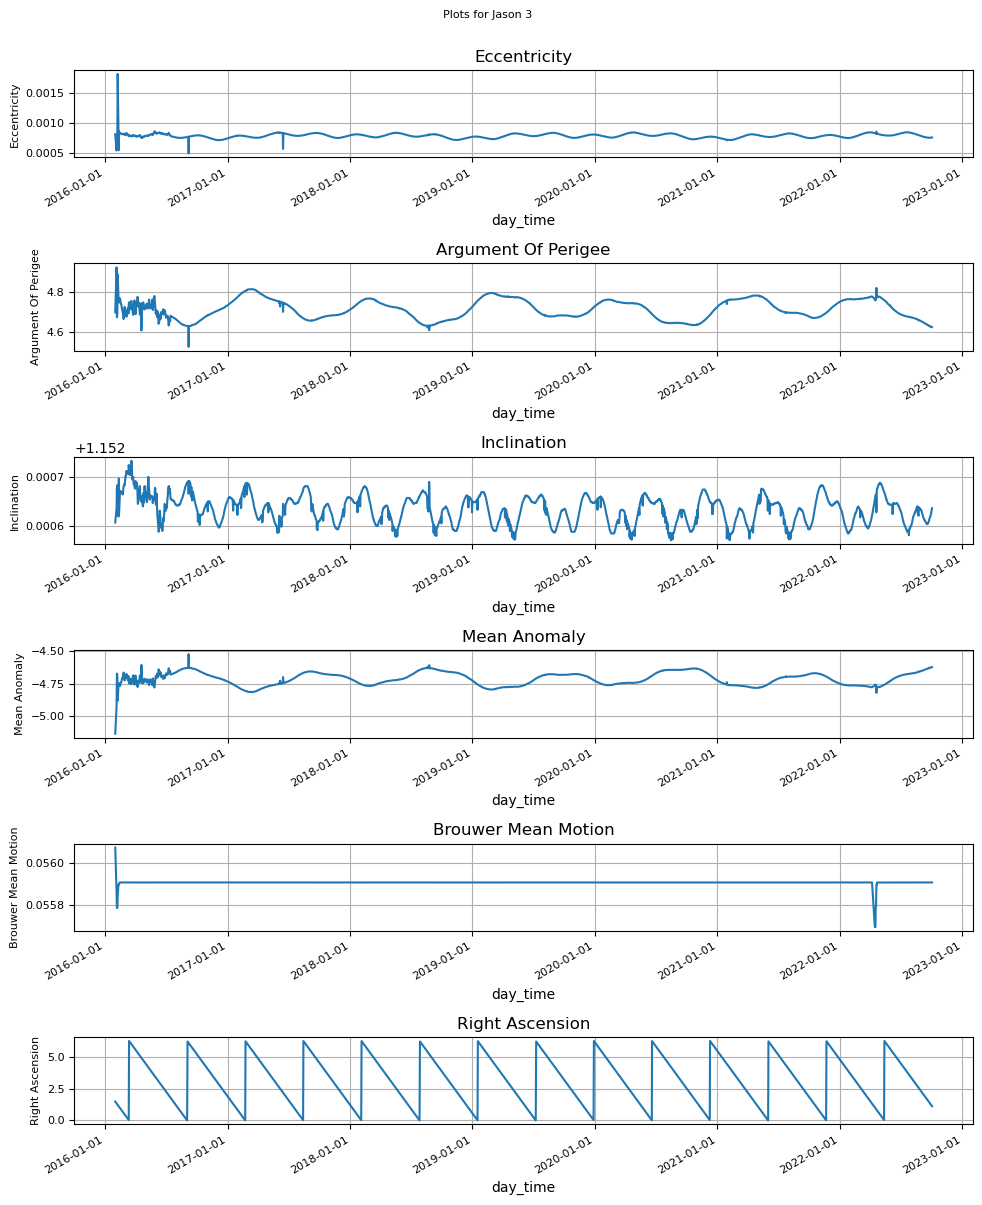

In [43]:
ja3orb['day_time'] = pd.to_datetime(ja3orb['day_time'], errors='coerce')
ja3orb.set_index('day_time', inplace=True)

# Get the columns to plot
columns_to_plot = ja3orb.columns
num_columns = len(columns_to_plot)

# Create a figure with subplots for each column
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 2*num_columns), sharex=False)

# Plot each column in its own subplot
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    ja3orb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x',  labelsize=8)
    ax.tick_params(axis='y',  labelsize=8)

# Adjust layout and show plot
plt.suptitle("Plots for Jason 3", y=1, fontsize=8)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

## SARAL

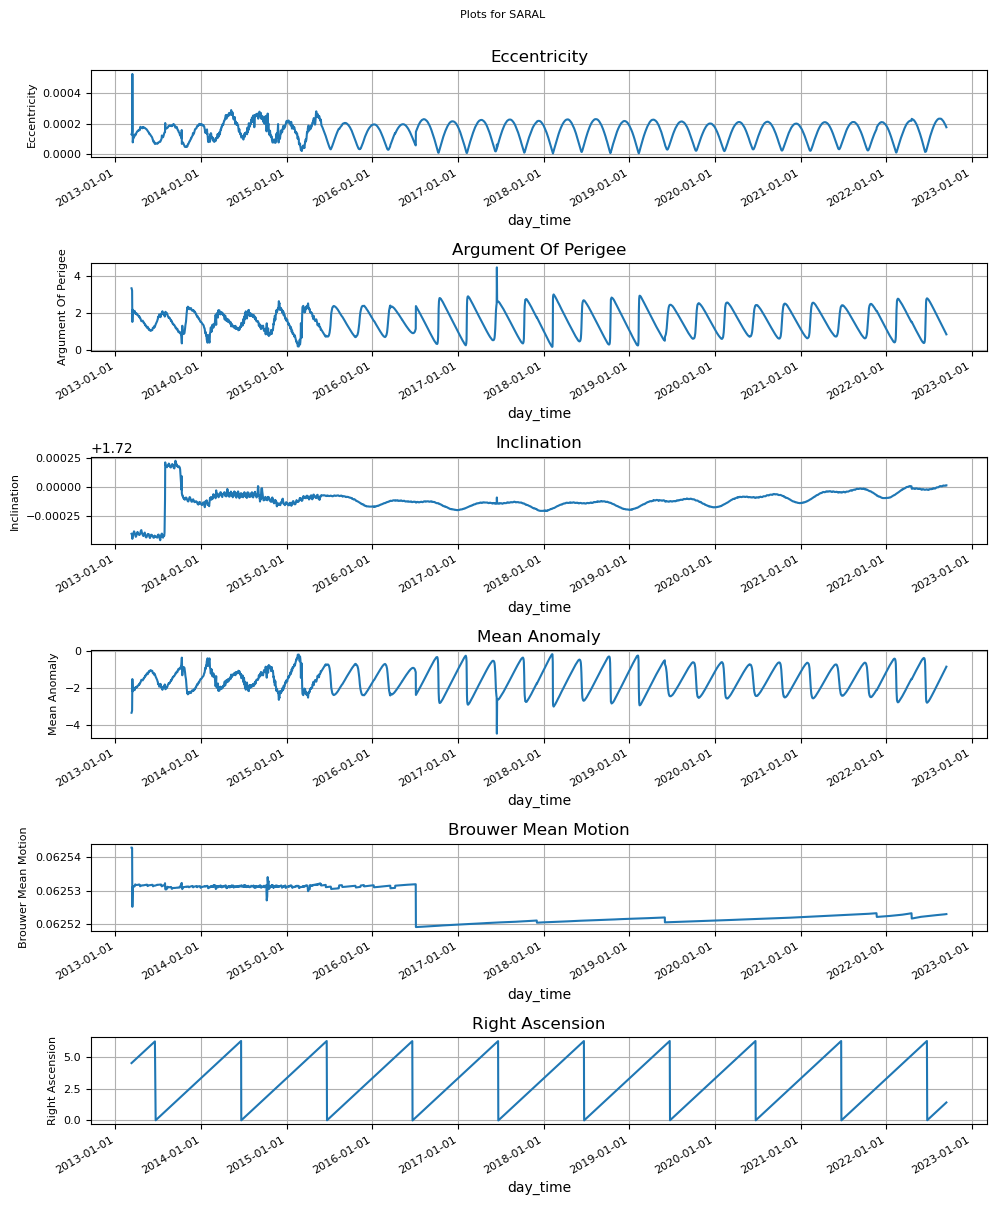

In [44]:
srlorb['day_time'] = pd.to_datetime(srlorb['day_time'], errors='coerce')
srlorb.set_index('day_time', inplace=True)

# Get the columns to plot
columns_to_plot = srlorb.columns
num_columns = len(columns_to_plot)

# Create a figure with subplots for each column
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 2*num_columns), sharex=False)

# Plot each column in its own subplot
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    srlorb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x',  labelsize=8)
    ax.tick_params(axis='y',  labelsize=8)

# Adjust layout and show plot
plt.suptitle("Plots for SARAL", y=1, fontsize=8)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

## SENTINEL3A

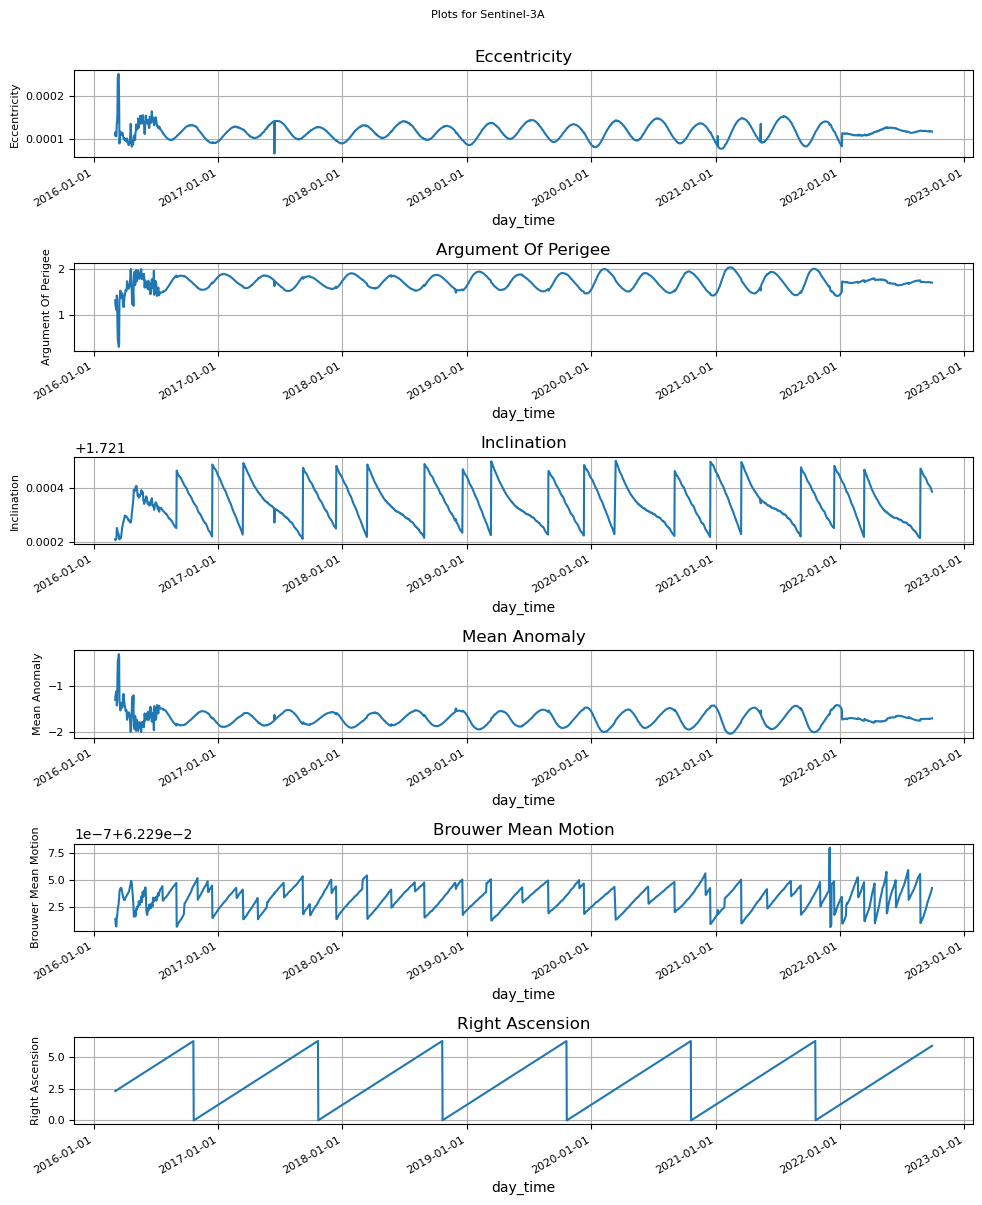

In [45]:
s3aorb['day_time'] = pd.to_datetime(s3aorb['day_time'], errors='coerce')
s3aorb.set_index('day_time', inplace=True)

# Get the columns to plot
columns_to_plot = s3aorb.columns
num_columns = len(columns_to_plot)

# Create a figure with subplots for each column
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 2*num_columns), sharex=False)

# Plot each column in its own subplot
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    s3aorb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x',  labelsize=8)
    ax.tick_params(axis='y',  labelsize=8)

# Adjust layout and show plot
plt.suptitle("Plots for Sentinel-3A", y=1, fontsize=8)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

## SENTINEL3B

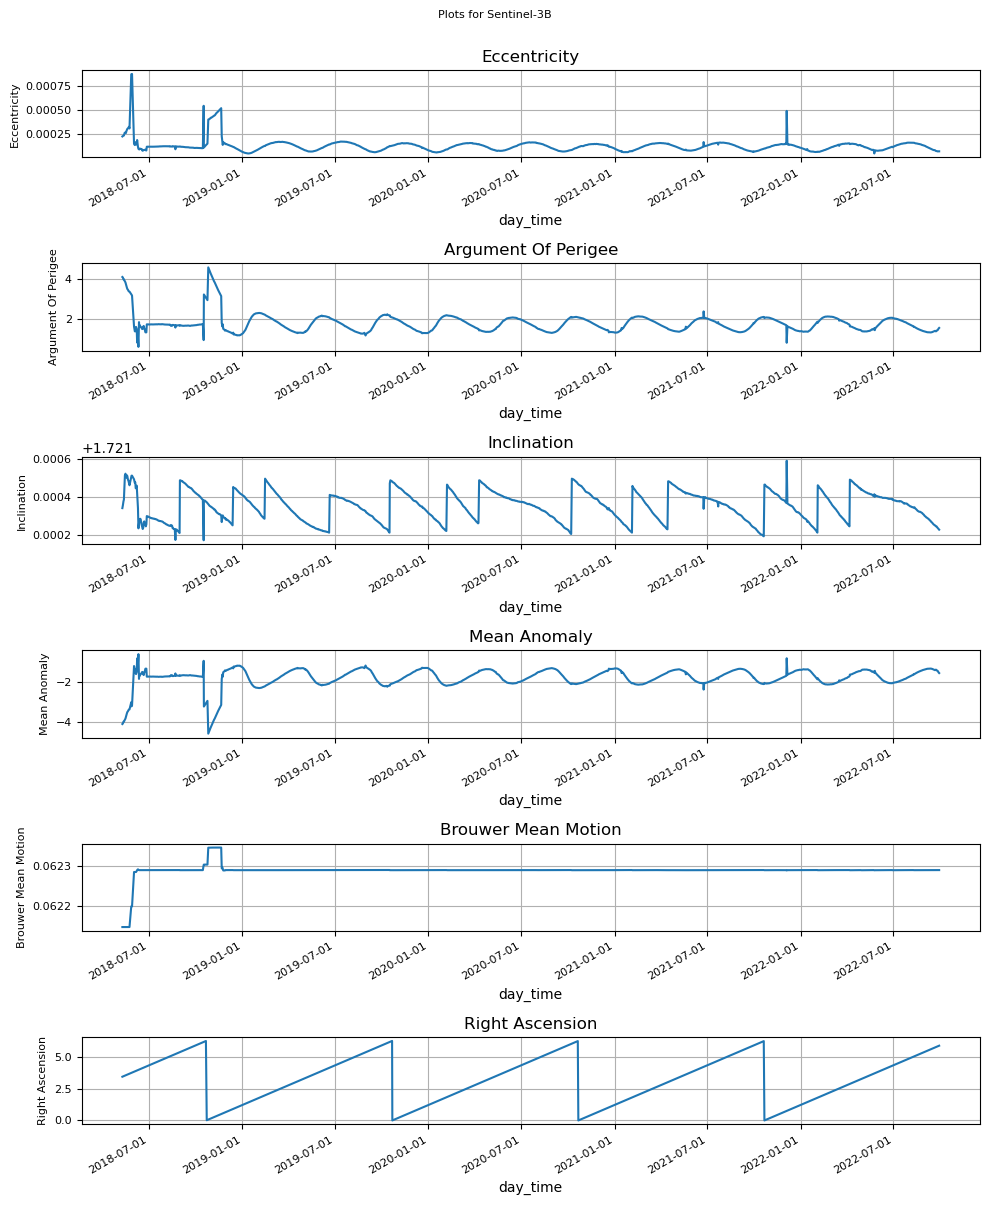

In [46]:
s3borb['day_time'] = pd.to_datetime(s3borb['day_time'], errors='coerce')
s3borb.set_index('day_time', inplace=True)

# Get the columns to plot
columns_to_plot = s3borb.columns
num_columns = len(columns_to_plot)

# Create a figure with subplots for each column
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 2*num_columns), sharex=False)

# Plot each column in its own subplot
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    s3borb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x',  labelsize=8)
    ax.tick_params(axis='y',  labelsize=8)

# Adjust layout and show plot
plt.suptitle("Plots for Sentinel-3B", y=1, fontsize=8)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

## SENTINEL6A

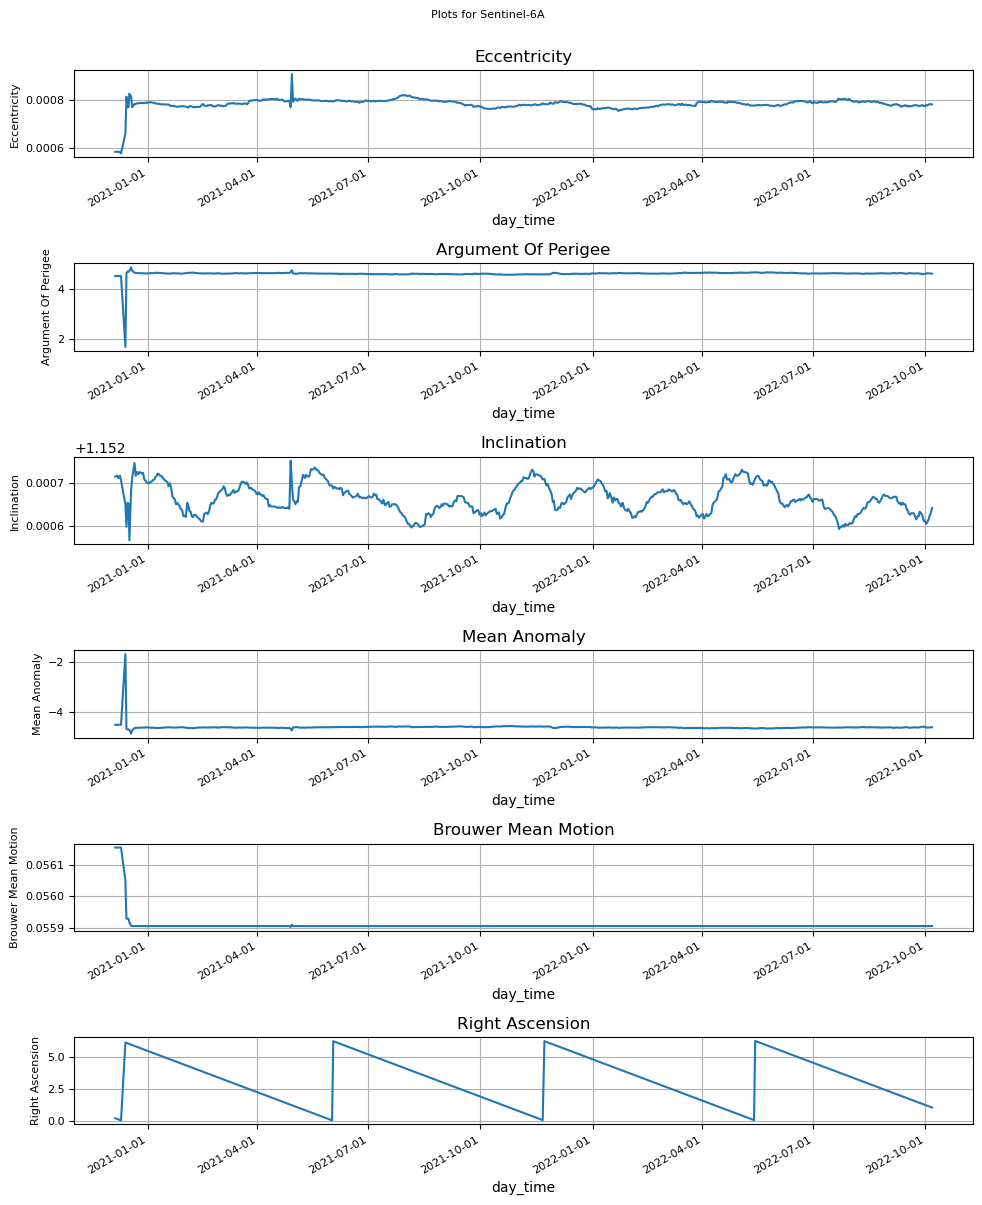

In [47]:
s6aorb['day_time'] = pd.to_datetime(s6aorb['day_time'], errors='coerce')
s6aorb.set_index('day_time', inplace=True)

# Get the columns to plot
columns_to_plot = s6aorb.columns
num_columns = len(columns_to_plot)

# Create a figure with subplots for each column
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 2*num_columns), sharex=False)

# Plot each column in its own subplot
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    s6aorb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x',  labelsize=8)
    ax.tick_params(axis='y',  labelsize=8)

# Adjust layout and show plot
plt.suptitle("Plots for Sentinel-6A", y=1, fontsize=8)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

## TOPEX

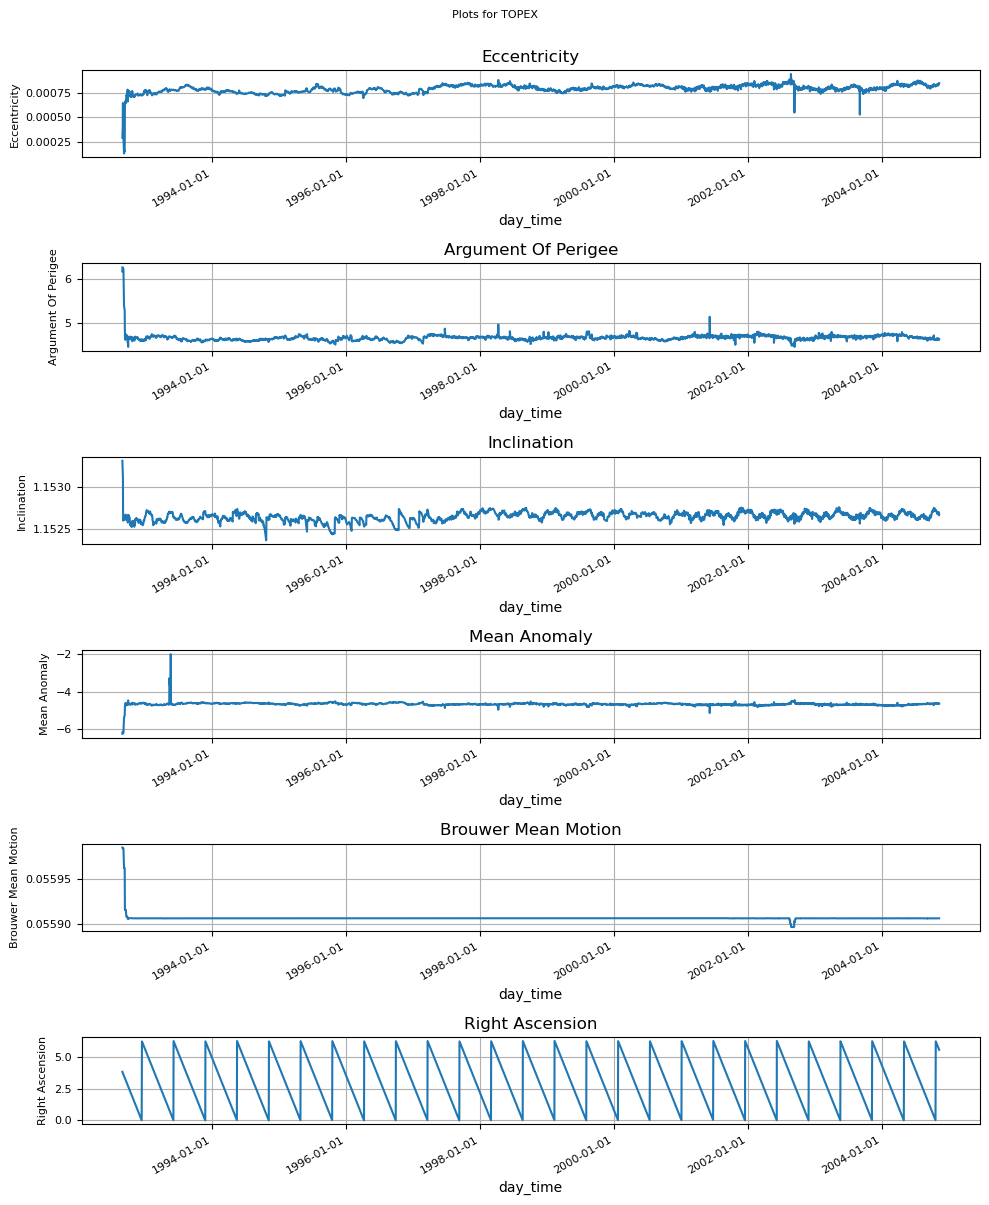

In [48]:
toporb['day_time'] = pd.to_datetime(toporb['day_time'], errors='coerce')
toporb.set_index('day_time', inplace=True)

# Get the columns to plot
columns_to_plot = toporb.columns
num_columns = len(columns_to_plot)

# Create a figure with subplots for each column
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 2*num_columns), sharex=False)

# Plot each column in its own subplot
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    toporb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x',  labelsize=8)
    ax.tick_params(axis='y',  labelsize=8)

# Adjust layout and show plot
plt.suptitle("Plots for TOPEX", y=1, fontsize=8)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

Consider to apply outliers remove. From some plts can see the mean motions actually might be outlier? - then replace with linear intereperetation methods?

mean anomy-nosie too big

# Check with manverous together

For particularly unusual spikes, consider leave them in the data for now, but also consider removing the outliers in the future.
This is because it is impossible to determine whether the data recording was incorrect or if the values are truly unusual.

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from pylab import rcParams
from scipy.fftpack import fft# Sort by time in case it's not already sorted

## CS2

In [ ]:
# Get the columns to plot from the orbital dataset
columns_to_plot = cs2orb.columns
num_columns = len(columns_to_plot)

# Extract maneuver timestamps from the maneuver dataset
cs2man = maneuver_data['cs2']
cs2man['median_day_time'] = pd.to_datetime(cs2man['median_day_time'], errors='coerce')

# Create a figure with subplots for each column, each with its own x-axis
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 3*num_columns), sharex=False)

# Plot each column in its own subplot with its own x-axis
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    cs2orb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)

    # Overlay maneuver events
    for _, row in cs2man.iterrows():
        if pd.notna(row['median_day_time']):
            ax.axvline(x=row['median_day_time'], color='red', linestyle='--', linewidth=0.8, label="Maneuver Median")

    # Format x-axis as Year-Month-Date for each subplot separately
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

# Adjust figure fonts
plt.suptitle("Plots for CryoSat-2 with Maneuver Events", fontsize=8, y=1)
plt.tight_layout()
plt.subplots_adjust(top=0.95)

plt.show()

## FY2D

In [ ]:
# Get the columns to plot from the orbital dataset
columns_to_plot = fy2dorb.columns
num_columns = len(columns_to_plot)

# Extract maneuver timestamps from the maneuver dataset
fy2dman = maneuver_data['FY2D']
fy2dman['median_day_time'] = pd.to_datetime(fy2dman['median_day_time'], errors='coerce')

# Create a figure with subplots for each column, each with its own x-axis
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 3*num_columns), sharex=False)

# Plot each column in its own subplot with its own x-axis
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    fy2dorb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)

    # Overlay maneuver events
    for _, row in fy2dman.iterrows():
        if pd.notna(row['median_day_time']):
            ax.axvline(x=row['median_day_time'], color='red', linestyle='--', linewidth=0.8, label="Maneuver Median")

    # Format x-axis as Year-Month-Date for each subplot separately
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

# Adjust figure fonts
plt.suptitle("Plots for Fengyun-2D with Maneuver Events", fontsize=8, y=1)
plt.tight_layout()
plt.subplots_adjust(top=0.95)

plt.show()

## FY2E

In [ ]:
# Get the columns to plot from the orbital dataset
columns_to_plot = fy2eorb.columns
num_columns = len(columns_to_plot)

# Extract maneuver timestamps from the maneuver dataset
fy2eman = maneuver_data['FY2E']
fy2eman['median_day_time'] = pd.to_datetime(fy2eman['median_day_time'], errors='coerce')

# Create a figure with subplots for each column, each with its own x-axis
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 3*num_columns), sharex=False)

# Plot each column in its own subplot with its own x-axis
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    fy2eorb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)

    # Overlay maneuver events
    for _, row in fy2eman.iterrows():
        if pd.notna(row['median_day_time']):
            ax.axvline(x=row['median_day_time'], color='red', linestyle='--', linewidth=0.8, label="Maneuver Median")

    # Format x-axis as Year-Month-Date for each subplot separately
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

# Adjust figure fonts
plt.suptitle("Plots for Fengyun-2E with Maneuver Events", fontsize=8, y=1)
plt.tight_layout()
plt.subplots_adjust(top=0.95)

plt.show()

## FY2F

In [ ]:
# Get the columns to plot from the orbital dataset
columns_to_plot = fy2forb.columns
num_columns = len(columns_to_plot)

# Extract maneuver timestamps from the maneuver dataset
fy2fman = maneuver_data['FY2F']
fy2fman['median_day_time'] = pd.to_datetime(fy2fman['median_day_time'], errors='coerce')

# Create a figure with subplots for each column, each with its own x-axis
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 3*num_columns), sharex=False)

# Plot each column in its own subplot with its own x-axis
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    fy2forb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)

    # Overlay maneuver events
    for _, row in fy2fman.iterrows():
        if pd.notna(row['median_day_time']):
            ax.axvline(x=row['median_day_time'], color='red', linestyle='--', linewidth=0.8, label="Maneuver Median")

    # Format x-axis as Year-Month-Date for each subplot separately
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

# Adjust figure fonts
plt.suptitle("Plots for Fengyun-2F with Maneuver Events", fontsize=8, y=1)
plt.tight_layout()
plt.subplots_adjust(top=0.95)

plt.show()

## FY2H

In [ ]:
# Get the columns to plot from the orbital dataset
columns_to_plot = fy2horb.columns
num_columns = len(columns_to_plot)

# Extract maneuver timestamps from the maneuver dataset
fy2hman = maneuver_data['FY2H']
fy2hman['median_day_time'] = pd.to_datetime(fy2hman['median_day_time'], errors='coerce')

# Create a figure with subplots for each column, each with its own x-axis
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 3*num_columns), sharex=False)

# Plot each column in its own subplot with its own x-axis
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    fy2horb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)

    # Overlay maneuver events
    for _, row in fy2hman.iterrows():
        if pd.notna(row['median_day_time']):
            ax.axvline(x=row['median_day_time'], color='red', linestyle='--', linewidth=0.8, label="Maneuver Median")

    # Format x-axis as Year-Month-Date for each subplot separately
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

# Adjust figure fonts
plt.suptitle("Plots for Fengyun-2H with Maneuver Events", fontsize=8, y=1)
plt.tight_layout()
plt.subplots_adjust(top=0.95)

plt.show()

## FY4A

In [ ]:
# Get the columns to plot from the orbital dataset
columns_to_plot = fy4aorb.columns
num_columns = len(columns_to_plot)

# Extract maneuver timestamps from the maneuver dataset
fy4aman = maneuver_data['FY4A']
fy4aman['median_day_time'] = pd.to_datetime(fy4aman['median_day_time'], errors='coerce')

# Create a figure with subplots for each column, each with its own x-axis
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 3*num_columns), sharex=False)

# Plot each column in its own subplot with its own x-axis
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    fy4aorb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)

    # Overlay maneuver events
    for _, row in fy4aman.iterrows():
        if pd.notna(row['median_day_time']):
            ax.axvline(x=row['median_day_time'], color='red', linestyle='--', linewidth=0.8, label="Maneuver Median")

    # Format x-axis as Year-Month-Date for each subplot separately
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

# Adjust figure fonts
plt.suptitle("Plots for Fengyun-4A with Maneuver Events", fontsize=8, y=1)
plt.tight_layout()
plt.subplots_adjust(top=0.95)

plt.show()

## HY2A

In [ ]:
# Get the columns to plot from the orbital dataset
columns_to_plot = h2aorb.columns
num_columns = len(columns_to_plot)

# Extract maneuver timestamps from the maneuver dataset
h2aman = maneuver_data['h2a']
h2aman['median_day_time'] = pd.to_datetime(h2aman['median_day_time'], errors='coerce')

# Create a figure with subplots for each column, each with its own x-axis
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 3*num_columns), sharex=False)

# Plot each column in its own subplot with its own x-axis
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    h2aorb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)

    # Overlay maneuver events
    for _, row in h2aman.iterrows():
        if pd.notna(row['median_day_time']):
            ax.axvline(x=row['median_day_time'], color='red', linestyle='--', linewidth=0.8, label="Maneuver Median")

    # Format x-axis as Year-Month-Date for each subplot separately
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

# Adjust figure fonts
plt.suptitle("Plots for Haiyang-2A with Maneuver Events", fontsize=8, y=1)
plt.tight_layout()
plt.subplots_adjust(top=0.95)

plt.show()

## JASON1

In [ ]:
# Get the columns to plot from the orbital dataset
columns_to_plot = ja1orb.columns
num_columns = len(columns_to_plot)

# Extract maneuver timestamps from the maneuver dataset
ja1man = maneuver_data['ja1']
ja1man['median_day_time'] = pd.to_datetime(ja1man['median_day_time'], errors='coerce')

# Create a figure with subplots for each column, each with its own x-axis
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 3*num_columns), sharex=False)

# Plot each column in its own subplot with its own x-axis
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    ja1orb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)

    # Overlay maneuver events
    for _, row in ja1man.iterrows():
        if pd.notna(row['median_day_time']):
            ax.axvline(x=row['median_day_time'], color='red', linestyle='--', linewidth=0.8, label="Maneuver Median")

    # Format x-axis as Year-Month-Date for each subplot separately
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

# Adjust figure fonts
plt.suptitle("Plots for Jason 1 with Maneuver Events", fontsize=8, y=1)
plt.tight_layout()
plt.subplots_adjust(top=0.95)

plt.show()

## JASON2

In [ ]:
# Get the columns to plot from the orbital dataset
columns_to_plot = ja2orb.columns
num_columns = len(columns_to_plot)

# Extract maneuver timestamps from the maneuver dataset
ja2man = maneuver_data['ja2']
ja2man['median_day_time'] = pd.to_datetime(ja2man['median_day_time'], errors='coerce')

# Create a figure with subplots for each column, each with its own x-axis
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 3*num_columns), sharex=False)

# Plot each column in its own subplot with its own x-axis
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    ja2orb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)

    # Overlay maneuver events
    for _, row in ja2man.iterrows():
        if pd.notna(row['median_day_time']):
            ax.axvline(x=row['median_day_time'], color='red', linestyle='--', linewidth=0.8, label="Maneuver Median")

    # Format x-axis as Year-Month-Date for each subplot separately
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

# Adjust figure fonts
plt.suptitle("Plots for Jason 2 with Maneuver Events", fontsize=8, y=1)
plt.tight_layout()
plt.subplots_adjust(top=0.95)

plt.show()

## JASON3

In [ ]:
# Get the columns to plot from the orbital dataset
columns_to_plot = ja3orb.columns
num_columns = len(columns_to_plot)

# Extract maneuver timestamps from the maneuver dataset
ja3man = maneuver_data['ja3']
ja3man['median_day_time'] = pd.to_datetime(ja3man['median_day_time'], errors='coerce')

# Create a figure with subplots for each column, each with its own x-axis
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 3*num_columns), sharex=False)

# Plot each column in its own subplot with its own x-axis
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    ja3orb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)

    # Overlay maneuver events
    for _, row in ja3man.iterrows():
        if pd.notna(row['median_day_time']):
            ax.axvline(x=row['median_day_time'], color='red', linestyle='--', linewidth=0.8, label="Maneuver Median")

    # Format x-axis as Year-Month-Date for each subplot separately
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

# Adjust figure fonts
plt.suptitle("Plots for Jason 3 with Maneuver Events", fontsize=8, y=1)
plt.tight_layout()
plt.subplots_adjust(top=0.95)

plt.show()

## SARAL

In [ ]:
# Get the columns to plot from the orbital dataset
columns_to_plot = srlorb.columns
num_columns = len(columns_to_plot)

# Extract maneuver timestamps from the maneuver dataset
srlman = maneuver_data['srl']
srlman['median_day_time'] = pd.to_datetime(srlman['median_day_time'], errors='coerce')

# Create a figure with subplots for each column, each with its own x-axis
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 3*num_columns), sharex=False)

# Plot each column in its own subplot with its own x-axis
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    srlorb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)

    # Overlay maneuver events
    for _, row in srlman.iterrows():
        if pd.notna(row['median_day_time']):
            ax.axvline(x=row['median_day_time'], color='red', linestyle='--', linewidth=0.8, label="Maneuver Median")

    # Format x-axis as Year-Month-Date for each subplot separately
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

# Adjust figure fonts
plt.suptitle("Plots for SARAL with Maneuver Events", fontsize=8, y=1)
plt.tight_layout()
plt.subplots_adjust(top=0.95)

plt.show()

## SENTINEL3A

In [ ]:
# Get the columns to plot from the orbital dataset
columns_to_plot = s3aorb.columns
num_columns = len(columns_to_plot)

# Extract maneuver timestamps from the maneuver dataset
s3aman = maneuver_data['s3a']
s3aman['median_day_time'] = pd.to_datetime(s3aman['median_day_time'], errors='coerce')

# Create a figure with subplots for each column, each with its own x-axis
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 3*num_columns), sharex=False)

# Plot each column in its own subplot with its own x-axis
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    s3aorb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)

    # Overlay maneuver events
    for _, row in s3aman.iterrows():
        if pd.notna(row['median_day_time']):
            ax.axvline(x=row['median_day_time'], color='red', linestyle='--', linewidth=0.8, label="Maneuver Median")

    # Format x-axis as Year-Month-Date for each subplot separately
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

# Adjust figure fonts
plt.suptitle("Plots for Sentinel-3A with Maneuver Events", fontsize=8, y=1)
plt.tight_layout()
plt.subplots_adjust(top=0.95)

plt.show()

## SENTINEL3B

In [ ]:
# Get the columns to plot from the orbital dataset
columns_to_plot = s3borb.columns
num_columns = len(columns_to_plot)

# Extract maneuver timestamps from the maneuver dataset
s3bman = maneuver_data['s3b']
s3bman['median_day_time'] = pd.to_datetime(s3bman['median_day_time'], errors='coerce')

# Create a figure with subplots for each column, each with its own x-axis
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 3*num_columns), sharex=False)

# Plot each column in its own subplot with its own x-axis
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    s3borb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)

    # Overlay maneuver events
    for _, row in s3bman.iterrows():
        if pd.notna(row['median_day_time']):
            ax.axvline(x=row['median_day_time'], color='red', linestyle='--', linewidth=0.8, label="Maneuver Median")

    # Format x-axis as Year-Month-Date for each subplot separately
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

# Adjust figure fonts
plt.suptitle("Plots for Sentinel-3B with Maneuver Events", fontsize=8, y=1)
plt.tight_layout()
plt.subplots_adjust(top=0.95)

plt.show()

## SENTINEL6A

In [ ]:
# Get the columns to plot from the orbital dataset
columns_to_plot = s6aorb.columns
num_columns = len(columns_to_plot)

# Extract maneuver timestamps from the maneuver dataset
s6aman = maneuver_data['s6a']
s6aman['median_day_time'] = pd.to_datetime(s6aman['median_day_time'], errors='coerce')

# Create a figure with subplots for each column, each with its own x-axis
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 3*num_columns), sharex=False)

# Plot each column in its own subplot with its own x-axis
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    s6aorb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)

    # Overlay maneuver events
    for _, row in s6aman.iterrows():
        if pd.notna(row['median_day_time']):
            ax.axvline(x=row['median_day_time'], color='red', linestyle='--', linewidth=0.8, label="Maneuver Median")

    # Format x-axis as Year-Month-Date for each subplot separately
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

# Adjust figure fonts
plt.suptitle("Plots for Sentinel-6A with Maneuver Events", fontsize=8, y=1)
plt.tight_layout()
plt.subplots_adjust(top=0.95)

plt.show()

## TOPEX

In [ ]:
# Get the columns to plot from the orbital dataset
columns_to_plot = toporb.columns
num_columns = len(columns_to_plot)

# Extract maneuver timestamps from the maneuver dataset
topman = maneuver_data['TOP']
topman = topman.copy()
topman['median_day_time'] = pd.to_datetime(topman['median_day_time'], errors='coerce')

# Create a figure with subplots for each column, each with its own x-axis
fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(10, 3*num_columns), sharex=False)

# Plot each column in its own subplot with its own x-axis
for x, column in enumerate(columns_to_plot):
    ax = axes[x] if num_columns > 1 else axes  # Handle single-column case
    toporb[column].plot(ax=ax, title=column.replace('_', ' ').title(), fontsize=8)
    ax.set_ylabel(column.replace('_', ' ').title(), fontsize=8)
    ax.grid(True)

    # Overlay maneuver events
    for _, row in topman.iterrows():
        if pd.notna(row['median_day_time']):
            ax.axvline(x=row['median_day_time'], color='red', linestyle='--', linewidth=0.8, label="Maneuver Median")

    # Format x-axis as Year-Month-Date for each subplot separately
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

# Adjust figure fonts
plt.suptitle("Plots for TOPEX with Maneuver Events", fontsize=8, y=1)
plt.tight_layout()
plt.subplots_adjust(top=0.95)

plt.show()

# Save cleaned data for next analysis

In [ ]:
import pickle

In [ ]:
with open('orbitals.pkl', 'wb') as f:
    pickle.dump(orbitals, f)

In [ ]:
with open('maneuvers.pkl', 'wb') as f:
    pickle.dump(maneuver_data, f)

In [ ]:
# with open('cleaned_orbitals.pkl', 'rb') as f:
#     restored_data = pickle.load(f)

# with open('cleaned_maneuver.pkl', 'rb') as f:
#     restored_data = pickle.load(f)